This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - picking task batteries of 3 to 28 tasks.

In [21]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


In [22]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

# start with some U_true, in this simulation 5 parcels

In [4]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [5]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [6]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

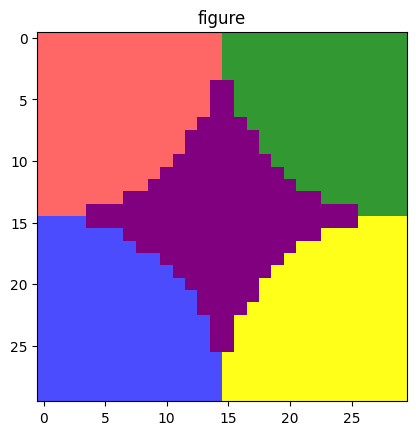

In [7]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

# Make a random task battery with 100 task and plot second moment matrix

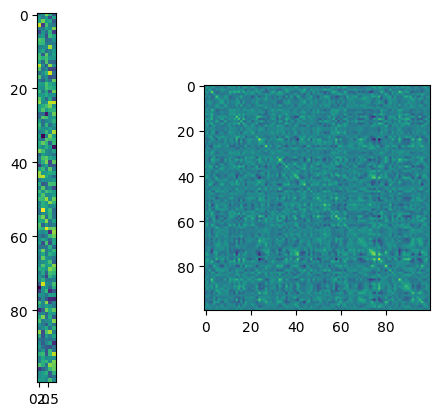

In [8]:
num_task_lib = 100
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

# prep inputs

In [9]:
Y_true = V_lib @ np.array(U_true_5)
Y_true = Y_true.reshape(1,Y_true.shape[0],Y_true.shape[1])
U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])


In [10]:
Y_true = pt.tensor(Y_true, dtype=pt.float32, device=device)
V_lib = pt.tensor(V_lib, dtype=pt.float32, device=device)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)

C:\Users\barafat\AppData\Local\Temp\ipykernel_20096\504040485.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)


# Run

In [11]:
# 2 to 24 steps of 2
battery_sizes = [3,4,6,8,10,14,18,24,28]
max_battery_size = max(battery_sizes)
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
noise = 5 # base noise level (will be weighted based on n_tasks and max_battery_size)
n_iter = 50 # how many "libraries to test" -> this is to integrate out the randomness when picking the top battery
n_batteries = 80000 # how many batteries to construct for each library

In [12]:
results_df = []
for i in range(n_iter):
    print(f"Iteration: {i}")
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_lib=G_lib, strategy='random',n_batteries=n_batteries,n_tasks=n_task,seed=i,replacement=False,rest_idx=None)
        for metric in metrics:
            if metric == 'random':
                # sample random battery
                index = rng.integers(0,D.shape[0])
                D_metric = D.iloc[[index]]
            else:
                D_metric = D.loc[[D[metric].idxmax()]]
            D_metric = D_metric.reset_index(drop=True)
            D_ev = sim.evluate_dataframe_simulation(D = D_metric, YLib= Y_true,VLib=V_lib,n_iter=1,noise=noise, U_true=U_true_5,method ='correlation', noise_method = 'weighted',max_n_task=max_battery_size)
            D_ev['n_task'] = n_task
            D_ev['metric'] = metric
            D_ev['iteration'] = i
            results_df.append(D_ev)
results_df = pd.concat(results_df)
results_df =results_df.reset_index(drop=True)
results_df['percent_correct'] = pd.to_numeric(results_df['percent_correct'], errors='coerce')


Iteration: 0
Processing battery size: 3
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 14
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 18
Processing comb

In [23]:
# Save results
# results_df.to_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_parcellation.tsv', index=False)
# #load results
results_df = pd.read_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_parcellation.tsv')


# plot

In [24]:

summary_df = results_df.groupby(['n_task', 'metric'])['percent_correct'].agg(
    mean_percent_correct='mean',
    sem_percent_correct=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

# Ensure numeric data types for plotting
summary_df['n_task'] = pd.to_numeric(summary_df['n_task'], errors='coerce')
summary_df['mean_percent_correct'] = pd.to_numeric(summary_df['mean_percent_correct'], errors='coerce')
summary_df['sem_percent_correct'] = pd.to_numeric(summary_df['sem_percent_correct'], errors='coerce')

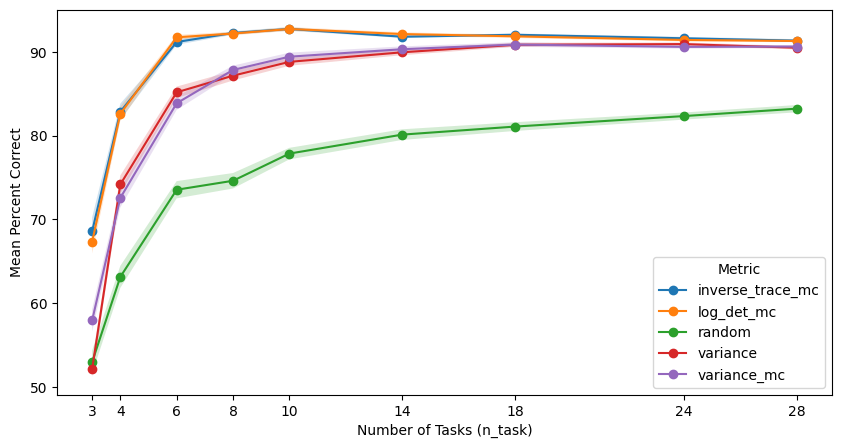

In [25]:
plt.figure(figsize=(10, 5))
for metric in summary_df['metric'].unique():
    subset = summary_df[summary_df['metric'] == metric]
    plt.plot(subset['n_task'], subset['mean_percent_correct'], marker='o', label=metric)
    plt.fill_between(subset['n_task'],
                     subset['mean_percent_correct'] - subset['sem_percent_correct'],
                     subset['mean_percent_correct'] + subset['sem_percent_correct'],
                     alpha=0.2) 

plt.xlabel("Number of Tasks (n_task)")
plt.xticks(battery_sizes)
plt.ylabel("Mean Percent Correct")
plt.legend(title="Metric")
plt.show()


# stats

In [26]:
def compute_corrected_pvals(results_df, battery_sizes, metrics, correction="bonferroni"):
    """Computes Bonferroni-corrected pairwise t-test p-values for each n_task."""
    pvals_list = []

    for n_t in battery_sizes:
        df_sub = results_df[results_df['n_task'] == n_t]
        pairs = list(itertools.combinations(metrics, 2))

        # ttest and collect pvals
        raw_pvals = [ttest_ind(df_sub[df_sub['metric'] == m1]['percent_correct'], 
                               df_sub[df_sub['metric'] == m2]['percent_correct'], 
                               equal_var=False)[1]
                     for m1, m2 in pairs]

        # multiple comparisons correction?
        _, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method=correction)
        for (idx, (m1, m2)) in enumerate(pairs):
            pvals_list.append({
                "n_task": n_t,
                "metric_1": m1,
                "metric_2": m2,
                "raw_p": raw_pvals[idx],
                "corrected_p": pvals_bonf[idx]
            })

    return pd.DataFrame(pvals_list)

In [27]:
pval_df = compute_corrected_pvals(results_df, battery_sizes, metrics)

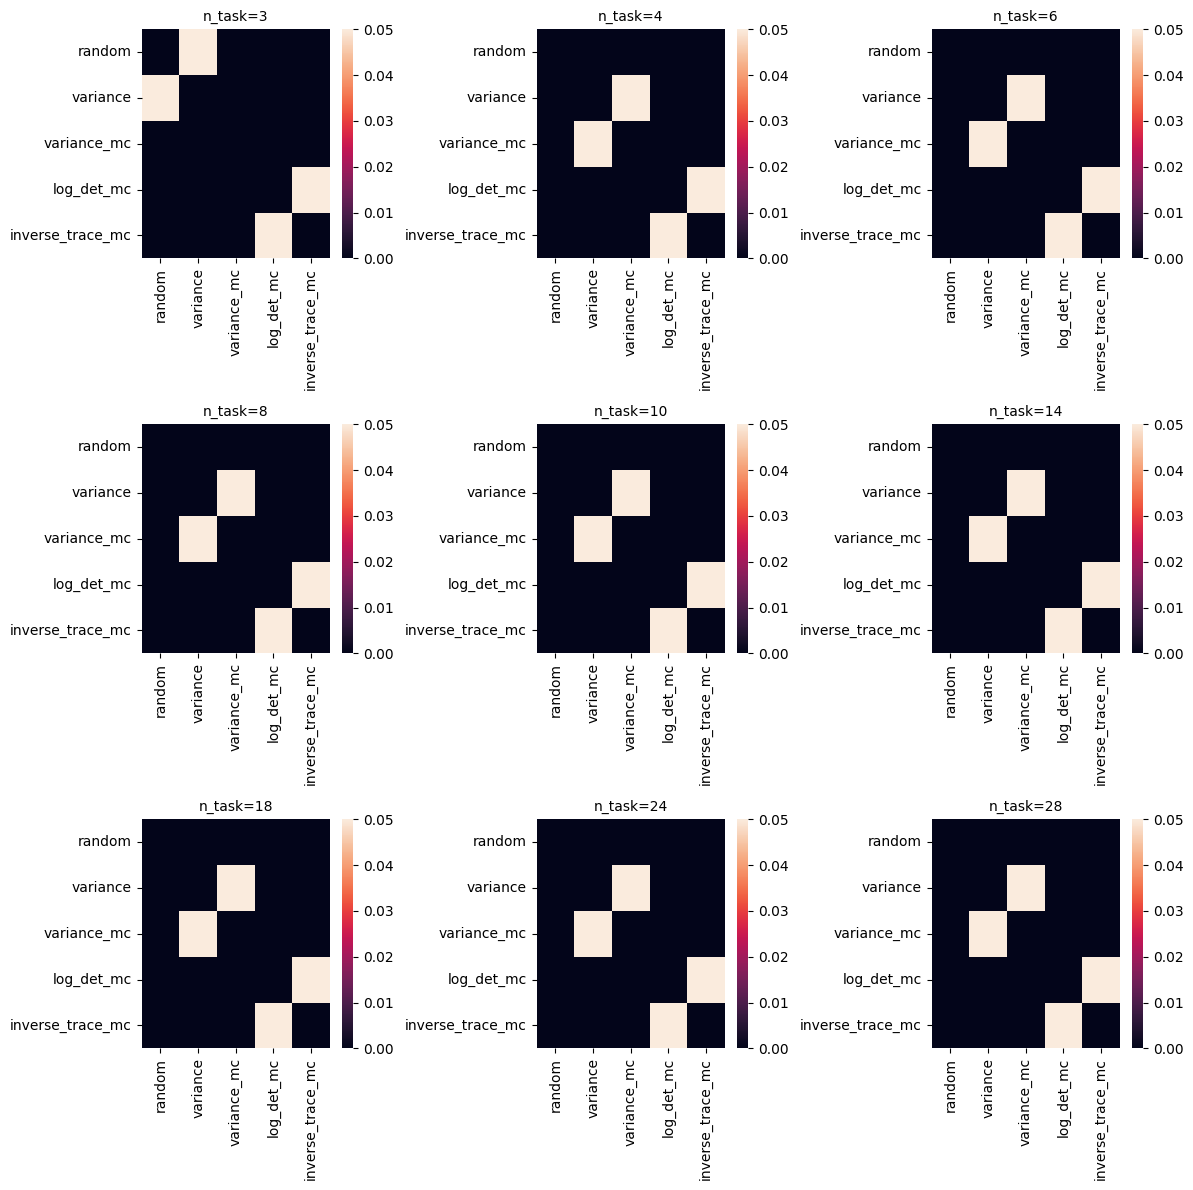

In [28]:
def plot_pval_heatmap(pval_table, battery_sizes, metrics):
    """Plots a heatmap of corrected p-values for each n_task."""
    num_n_tasks = len(battery_sizes)
    num_cols = 3 
    num_rows = (num_n_tasks + num_cols - 1) // num_cols 

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    axes = np.ravel(axes)  

    for i, n_t in enumerate(battery_sizes):
        ax = axes[i]
        df_sub = pval_table[pval_table["n_task"] == n_t]

        # initlize
        pval_matrix = np.full((len(metrics), len(metrics)), 0)

        # fill
        for _, row_data in df_sub.iterrows():
            i, j = metrics.index(row_data["metric_1"]), metrics.index(row_data["metric_2"])
            pval_matrix[i, j] = pval_matrix[j, i] = row_data["corrected_p"]

        #plot
        sns.heatmap(pval_matrix, xticklabels=metrics, 
                    yticklabels=metrics, cbar=True, vmin=0, vmax=0.05, ax=ax)

        ax.set_title(f"n_task={n_t}", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_pval_heatmap(pval_df, battery_sizes, metrics)
